# Setting a DateTime Index

---



Time Series Data in Pandas
---
Pandas contains extensive capabilities and features for working with [**time series data**](https://pandas.pydata.org/docs/user_guide/timeseries.html). For example, pandas supports:
 - **Parsing** time series information from various sources and formats
 - **Indexing** and **slicing** using the `DatetimeIndex` class with many time series specific optimizations

Things that datetime encoding can support you with:

 - **Accessing date/time components** 
 - **Generating sequences** of dates and time spans with absolute or calendar-based frequencies
 - Performing date and time [**arithmetic**](https://pandas.pydata.org/docs/user_guide/timedeltas.html) with absolute or calendar-based time increments, using `Timedelta` and `DateOffset`
 - Manipulating and converting date times with **timezone** information
 - **Resampling** or converting time series to different frequencies, with various aggregation, filling and interpolation logic
 - **Windowing** operations that respect absolute or calendar-based intervals

In [1]:
import pandas as pd
import datetime

### Getting Time Series Data into Pandas
Pandas read methods allow for columns to be parsed as dates. Pandas uses the [**dateutil**](https://pypi.org/project/python-dateutil/) library under the hood, which extends the standard `datetime` library with some powerful parsing methods (amongst other things).

#### When reading from .csv, we can parse the index and/or columns as dates by specifying a `parse_dates` argument
The seaice dataset has a "Date" column. This data is stored as a string in the csv. We can set this as the `index_col`, but for pandas to be aware that it contains DateTime date, we need to parse it as a date explicitly by providing `parse_dates=True`.

##### parse_dates not set

In [2]:
# without parse_dates=True, the index is created as a standard Index with dtype='object'
seaice = pd.read_csv('../data/seaice.csv', index_col='Date')

seaice.index

Index(['1980-01-01', '1980-01-03', '1980-01-05', '1980-01-07', '1980-01-09',
       '1980-01-11', '1980-01-13', '1980-01-15', '1980-01-17', '1980-01-19',
       ...
       '2019-12-22', '2019-12-23', '2019-12-24', '2019-12-25', '2019-12-26',
       '2019-12-27', '2019-12-28', '2019-12-29', '2019-12-30', '2019-12-31'],
      dtype='object', name='Date', length=13175)

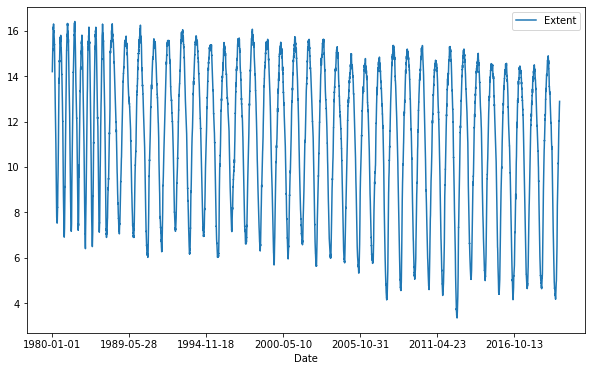

In [3]:
# when plotting this data, pandas will just use dates spaced at regular intervals on the x-axis with no reference to calendar meaning
seaice.plot(figsize=(10,6));

##### parse_dates=True

In [4]:
# with parse_dates=True, the index is created as a DateTimeIndex with dtype='datetime64[ns]'
seaice = pd.read_csv('../data/seaice.csv', index_col='Date', parse_dates=True)

seaice.index

DatetimeIndex(['1980-01-01', '1980-01-03', '1980-01-05', '1980-01-07',
               '1980-01-09', '1980-01-11', '1980-01-13', '1980-01-15',
               '1980-01-17', '1980-01-19',
               ...
               '2019-12-22', '2019-12-23', '2019-12-24', '2019-12-25',
               '2019-12-26', '2019-12-27', '2019-12-28', '2019-12-29',
               '2019-12-30', '2019-12-31'],
              dtype='datetime64[ns]', name='Date', length=13175, freq=None)

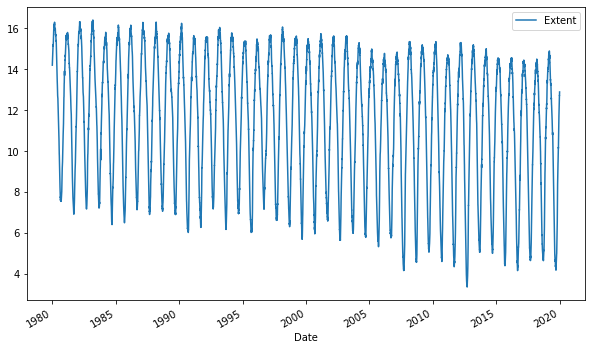

In [5]:
# when plotting this data, pandas will choose meaningful calendar concepts for its x-axis labels
seaice.plot(figsize=(10,6));

###

## Indexing / accessing time series data using `.loc[]`
Pandas objects indexed with a `DatetimeIndex` can make use of many time series related optimizations. In particular, dates and strings that parse to timestamps or periods can be passed as indexing parameters. Slices can be naturally specified with these strings too.





In [6]:
seaice.loc['2014']



,Extent
Date,
2014-01-01,13.011
2014-01-02,13.103
2014-01-03,13.116
2014-01-04,13.219
2014-01-05,13.148
...,...
2014-12-27,12.967
2014-12-28,12.930
2014-12-29,12.936


In [7]:
seaice.loc['2014-Q2']



,Extent
Date,
2014-04-01,14.541
2014-04-02,14.541
2014-04-03,14.475
2014-04-04,14.573
2014-04-05,14.610
...,...
2014-06-26,10.236
2014-06-27,10.063
2014-06-28,9.835


In [8]:
seaice.loc['2014-03']


,Extent
Date,
2014-03-01,14.629
2014-03-02,14.658
2014-03-03,14.688
2014-03-04,14.720
2014-03-05,14.811
2014-03-06,14.804
2014-03-07,14.773
2014-03-08,14.559
2014-03-09,14.616


In [9]:

seaice.loc['2014-03-07':'2014-03-11']

,Extent
Date,
2014-03-07,14.773
2014-03-08,14.559
2014-03-09,14.616
2014-03-10,14.617
2014-03-11,14.711
